In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("Dataset/netflix_titles.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/netflix_titles.csv'

In [3]:
import os

print(os.getcwd())

C:\Data-Analyst_Projects\Netflix-Data-Analysis\Notebook


In [4]:
df = pd.read_csv("../Dataset/netflix_titles.csv")

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (8807, 12)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [13]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [14]:
print("Content Types:")
print(df["type"].value_counts())

print("\nRatings:")
print(df["rating"].value_counts())

Content Types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Ratings:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


# Dataset Overview

- Dataset contains Movies and TV Shows available on Netflix.
- Total records and columns analyzed.
- Data includes title, director, cast, country, release year, rating, duration and genres.
- Missing values are present in some columns such as director and country.

# Analysis 1: Movies vs TV Shows Distribution

In [15]:
content_type = df["type"].value_counts()

print(content_type)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


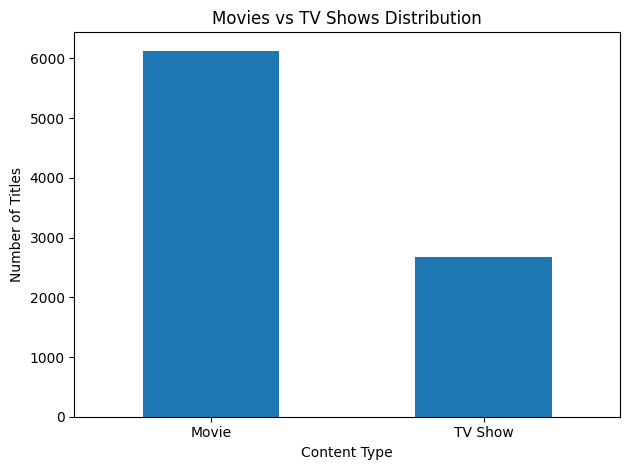

In [19]:
content_type.plot(kind="bar")

plt.title("Movies vs TV Shows Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../Screenshots/movies_vs_tvshows.png", dpi=300)

plt.show()

## Business Insight

- Movies account for the majority of Netflix's content library.
- TV Shows represent a smaller portion of the catalog.
- This suggests Netflix focuses more on movies while maintaining a diverse selection of TV Shows.
- Understanding content distribution helps identify Netflix's overall content strategy.

# Analysis 2: Top 10 Countries by Netflix Content

In [20]:
top_countries = df["country"].dropna().value_counts().head(10)

print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


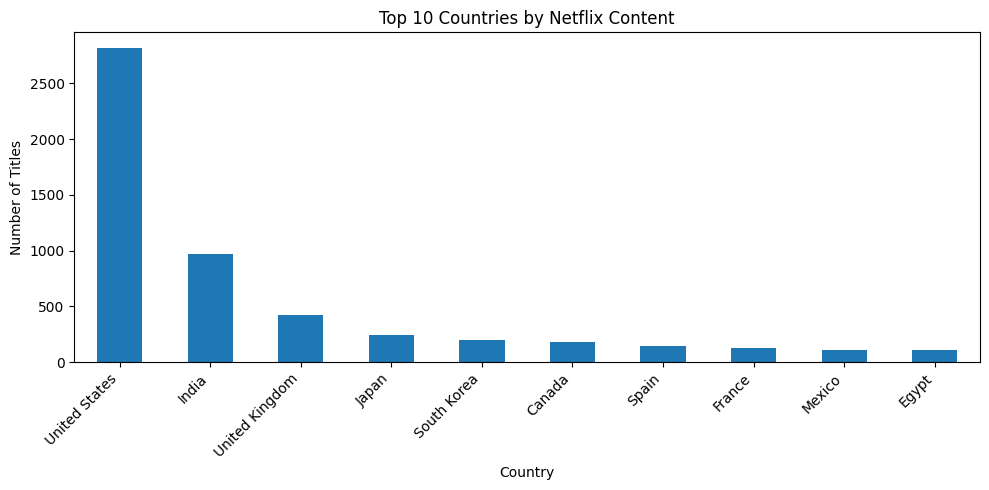

In [21]:
plt.figure(figsize=(10,5))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../Screenshots/top_10_countries.png", dpi=300)

plt.show()

## Business Insight

- The United States contributes the highest number of titles on Netflix.
- India, the United Kingdom, Canada, and Japan are also major content-producing countries.
- Netflix offers content from multiple regions, highlighting its strong global presence.
- Country-wise analysis helps understand content distribution and regional market focus.

# Analysis 3: Top 10 Content Ratings

In [22]:
top_ratings = df["rating"].dropna().value_counts().head(10)

print(top_ratings)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


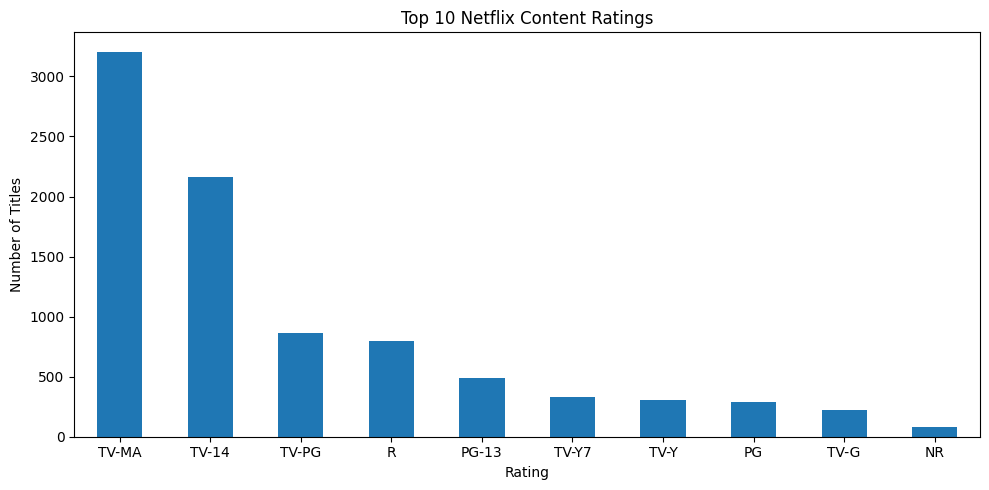

In [23]:
plt.figure(figsize=(10,5))

top_ratings.plot(kind="bar")

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../Screenshots/top_10_ratings.png", dpi=300)

plt.show()

## Business Insight

- TV-MA is the most common content rating on Netflix.
- Mature audience content dominates the platform.
- TV-14 is the second most common rating, indicating a strong focus on teenage and young adult viewers.
- Understanding content ratings helps Netflix target different audience segments effectively.

# Analysis 4: Content Released by Year

In [24]:
release_year = df["release_year"].value_counts().sort_index()

print(release_year.tail(10))

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


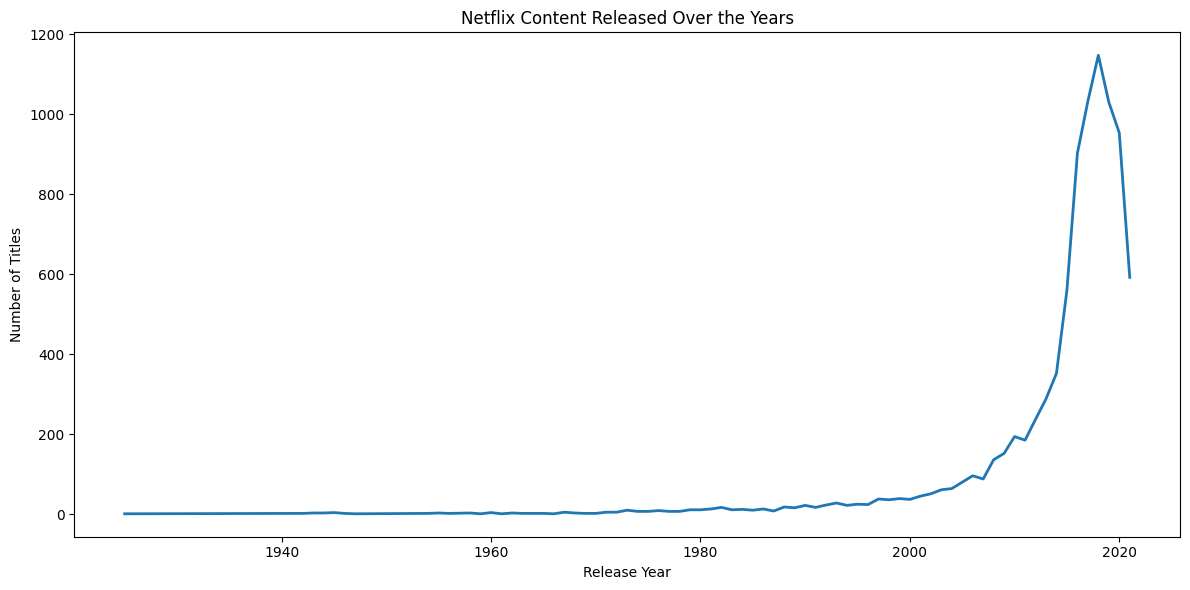

In [25]:
plt.figure(figsize=(12,6))

release_year.plot(kind="line", linewidth=2)

plt.title("Netflix Content Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("../Screenshots/content_by_release_year.png", dpi=300)

plt.show()

## Business Insight

- Netflix's content library has grown significantly over the years.
- The highest number of titles were released in recent years.
- This indicates Netflix has consistently expanded its content production and acquisitions.

# Analysis 5: Top 10 Genres

In [26]:
genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


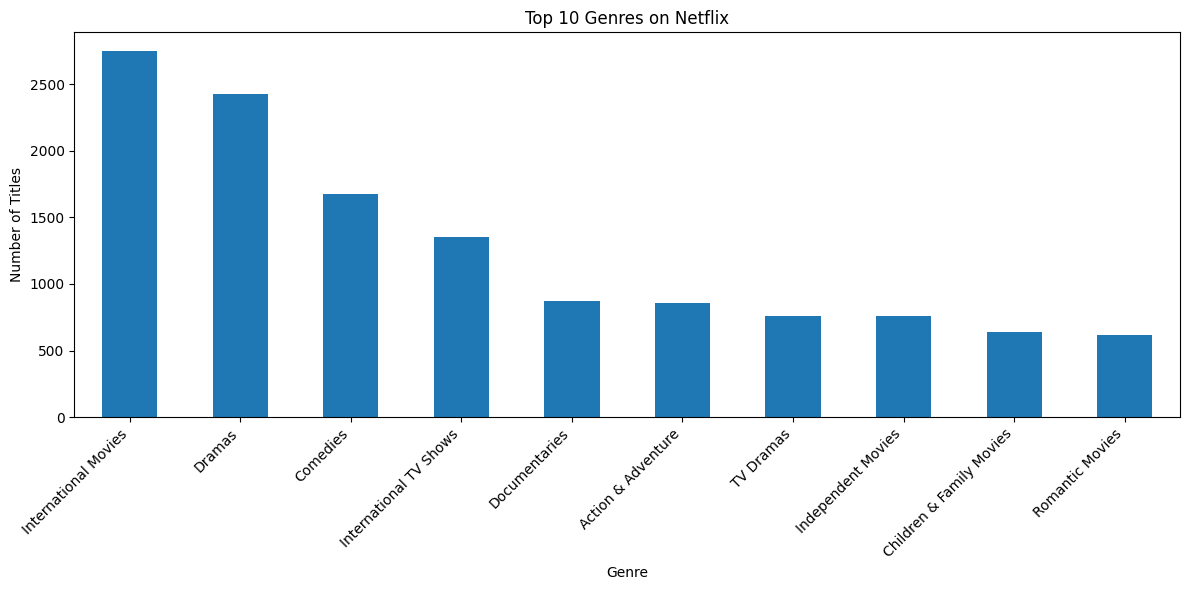

In [27]:
plt.figure(figsize=(12,6))

top_genres.plot(kind="bar")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../Screenshots/top_10_genres.png", dpi=300)

plt.show()

## Business Insight

- International Movies and Dramas are among the most common genres.
- Netflix offers a diverse catalog across multiple genres.
- Genre analysis helps understand audience preferences and content strategy.

# Analysis 6: Top 10 Directors

In [28]:
top_directors = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

print(top_directors)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


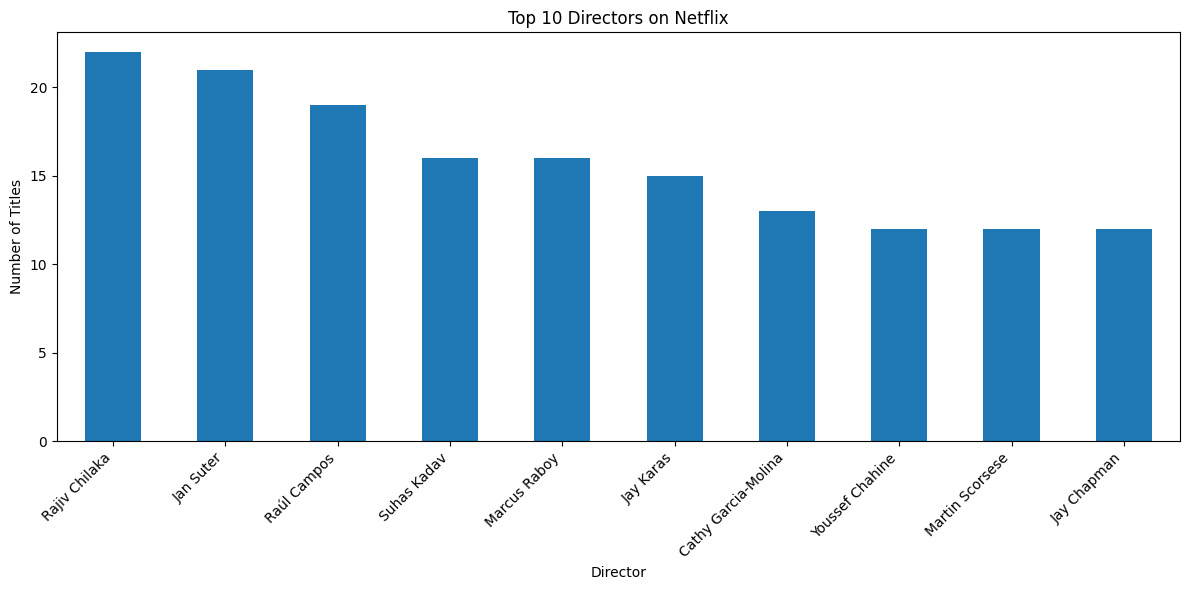

In [29]:
plt.figure(figsize=(12,6))

top_directors.plot(kind="bar")

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../Screenshots/top_10_directors.png", dpi=300)

plt.show()

## Business Insight

- A few directors have contributed multiple titles to Netflix.
- This indicates long-term collaborations with successful filmmakers.
- Director analysis helps identify key content creators on the platform.

# Analysis 7: Top 10 Actors

In [30]:
top_actors = (
    df["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

print(top_actors)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


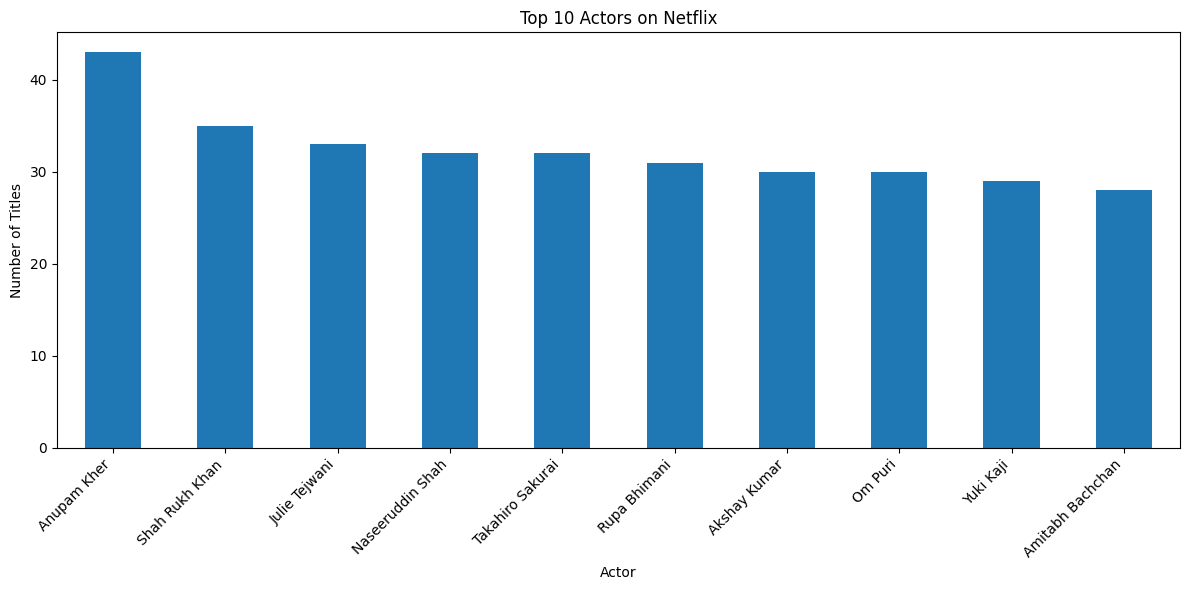

In [31]:
plt.figure(figsize=(12,6))

top_actors.plot(kind="bar")

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../Screenshots/top_10_actors.png", dpi=300)

plt.show()

## Business Insight

- Some actors appear in a significantly higher number of Netflix titles.
- Frequent appearances indicate strong audience demand and recurring collaborations.
- Actor analysis provides insight into Netflix's content portfolio.

# Analysis 8: Movie Duration Distribution

In [33]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

movies["duration"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

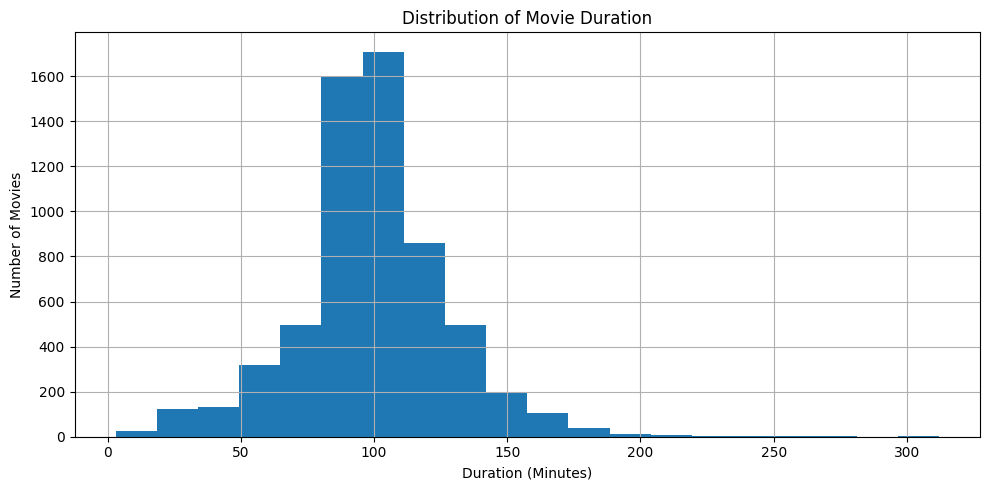

In [34]:
plt.figure(figsize=(10,5))

movies["duration"].dropna().hist(bins=20)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig("../Screenshots/movie_duration_distribution.png", dpi=300)

plt.show()

## Business Insight

- Most Netflix movies are between 80 and 120 minutes long.
- Extremely short and very long movies are relatively uncommon.
- This suggests Netflix primarily offers standard feature-length films.

# Analysis 9: Content Added to Netflix by Year

In [35]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

added_year = df["date_added"].dt.year.value_counts().sort_index()

print(added_year)

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


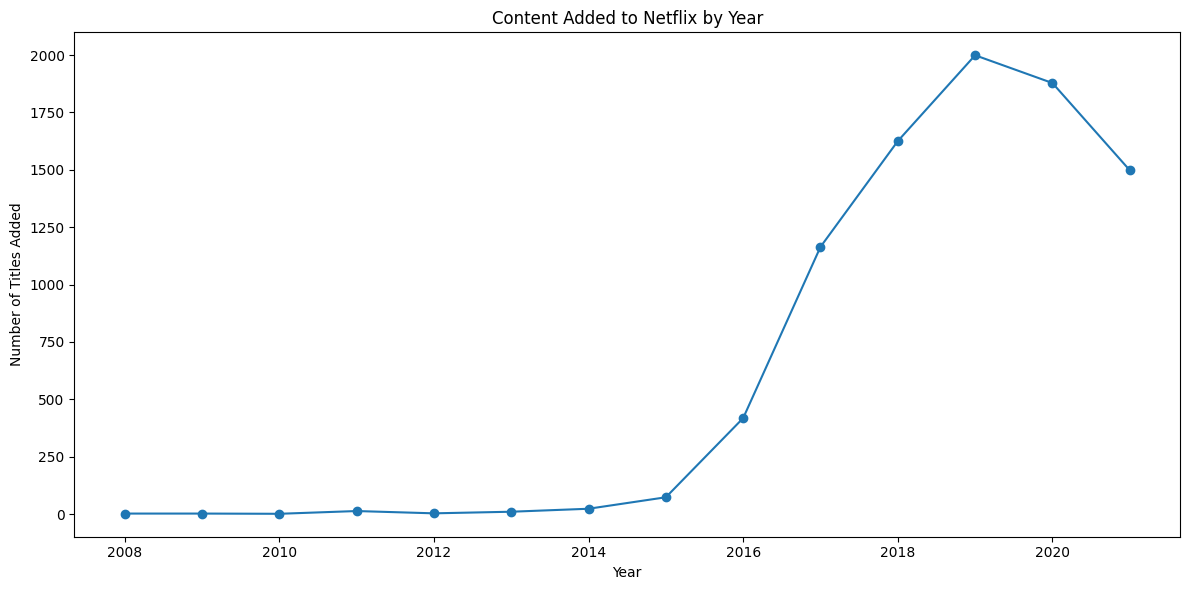

In [36]:
plt.figure(figsize=(12,6))

added_year.plot(kind="line", marker="o")

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.tight_layout()

plt.savefig("../Screenshots/content_added_by_year.png", dpi=300)

plt.show()

## Business Insight

- Netflix significantly increased content additions after 2015.
- The platform experienced rapid expansion in its content library during recent years.
- Consistent content acquisition supports subscriber growth and engagement.

# Final Conclusion

## Key Findings

- Movies dominate the Netflix catalog compared to TV Shows.
- The United States contributes the largest share of content.
- TV-MA is the most common content rating.
- Netflix's content library has grown rapidly over the years.
- International Movies and Dramas are among the most popular genres.
- Several directors and actors have multiple collaborations with Netflix.
- Most movies have a duration between 80–120 minutes.

## Skills Demonstrated

- Python
- Pandas
- NumPy
- Matplotlib
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Business Insights
- Data Visualization